# LSTM для анализа видео после YOLOv8

Этот ноутбук обучает LSTM-классификатор для видео `fire` / `non_fire`. YOLOv8 находит огонь и дым на отдельных кадрах, а LSTM анализирует последовательность признаков по времени.

Ожидаемая структура данных:

```text
videos/
  fire/
    video_001.mp4
    video_002.avi
  non_fire/
    video_101.mp4
    video_102.avi
```

По умолчанию используется обученная модель YOLO из проекта: `runs/fire_smoke_yolov8n/weights/best.pt`.

## 1. Установка зависимостей

Запустите ячейку, если пакеты еще не установлены.

%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install -U ultralytics opencv-python scikit-learn matplotlib tqdm joblib numpy

## 2. Импорты и настройки

In [2]:
from pathlib import Path
import json
import random
from dataclasses import dataclass

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "dataset").exists():
    PROJECT_ROOT = Path(r".")

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is not available. Install the CUDA PyTorch build from the first cell "
        "and check that the NVIDIA driver is installed."
    )

DEVICE = torch.device("cuda:0")
YOLO_DEVICE = 0
torch.cuda.set_device(DEVICE)
torch.backends.cudnn.benchmark = True
print(f"Using GPU: {torch.cuda.get_device_name(0)}")
DEVICE

Using GPU: NVIDIA GeForce RTX 3060


device(type='cuda', index=0)

In [3]:
@dataclass
class Config:
    videos_dir: Path = PROJECT_ROOT / "dataset"
    fire_dir_name: str = "fire"
    non_fire_dir_name: str = "non_fire"
    non_fire_alt_dir_name: str = "non-fire"
    yolo_weights: Path = PROJECT_ROOT / "yolo" / "best.pt"
    cache_dir: Path = PROJECT_ROOT / "lstm_cache"
    artifacts_dir: Path = PROJECT_ROOT / "lstm_artifacts"
    img_size: int = 640
    yolo_conf: float = 0.25
    use_yolo_trigger_crop: bool = True
    trigger_conf: float = 0.35
    trigger_consecutive_frames: int = 2
    trigger_max_scan_frames: int = 1500
    frame_step: int = 5
    max_frames: int = 3600               # Увеличено, чтобы брать видео целиком (до 10 минут)
    seq_len: int = 16
    seq_stride: int = 8
    batch_size: int = 64                 # Уменьшено, так как датасет станет меньше и чище
    epochs: int = 80
    lr: float = 3e-4
    hidden_size: int = 64                # Возвращаем 64, чтобы избежать переобучения на малых данных
    num_layers: int = 2
    dropout: float = 0.4
    bidirectional: bool = True
    weight_decay: float = 5e-4
    val_size: float = 0.25
    # ── Early stopping & LR scheduler ──
    patience: int = 10
    lr_patience: int = 5
    lr_factor: float = 0.5
    min_lr: float = 1e-6
    # ── Focal Loss & Regularization ──
    focal_gamma: float = 2.0
    feature_dropout: float = 0.1

CFG = Config()
CFG.cache_dir.mkdir(exist_ok=True)
CFG.artifacts_dir.mkdir(exist_ok=True)
CFG

Config(videos_dir=WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset'), fire_dir_name='fire', non_fire_dir_name='non_fire', non_fire_alt_dir_name='non-fire', yolo_weights=WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/yolo/best.pt'), cache_dir=WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/lstm_cache'), artifacts_dir=WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/lstm_artifacts'), img_size=640, yolo_conf=0.25, use_yolo_trigger_crop=True, trigger_conf=0.35, trigger_consecutive_frames=2, trigger_max_scan_frames=1500, frame_step=5, max_frames=3600, seq_len=16, seq_stride=8, batch_size=64, epochs=80, lr=0.0003, hidden_size=64, num_layers=2, dropout=0.4, bidirectional=True, weight_decay=0.0005, val_size=0.25, patience=10, lr_patience=5, lr_factor=0.5, min_lr=1e-06, focal_gamma=2.0, feature_dropout=0.1)

## 3. Поиск видео

Метка `1` означает `fire`, метка `0` означает `non_fire`.

In [4]:
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".m4v"}

def collect_videos(cfg: Config):
    fire_dir = cfg.videos_dir / cfg.fire_dir_name
    non_fire_dirs = [cfg.videos_dir / cfg.non_fire_dir_name, cfg.videos_dir / cfg.non_fire_alt_dir_name]
    items = []
    label_folders = [(1, [fire_dir]), (0, non_fire_dirs)]
    for label, folders in label_folders:
        existing_folders = [folder for folder in folders if folder.exists()]
        if not existing_folders:
            print("Папка не найдена:", " или ".join(str(folder) for folder in folders))
            continue
        for folder in existing_folders:
            for path in sorted(folder.rglob("*")):
                if path.suffix.lower() in VIDEO_EXTS:
                    items.append({"path": path, "label": label})
    return items

video_items = collect_videos(CFG)
print(f"Найдено видео: {len(video_items)}")
print(f"fire: {sum(x['label'] == 1 for x in video_items)}")
print(f"non_fire: {sum(x['label'] == 0 for x in video_items)}")
video_items[:5]

Найдено видео: 482
fire: 179
non_fire: 303


[{'path': WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset/fire/4K Footage Zoom Out Aerial Drone View Of Forest Fire Controlled Burn With Smoke On Farm_480p.mp4'),
  'label': 1},
 {'path': WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset/fire/A house catches on fire. Video shows the dog did it.-640x360-avc1-opus.mp4'),
  'label': 1},
 {'path': WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset/fire/A house catches on fire. Video shows the dog did it.-640x360-avc1-opus_trimmed.mp4'),
  'label': 1},
 {'path': WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset/fire/Aerial Footage Shows Scale of Fires in Australia-854x480-avc1-opus (1).mp4'),
  'label': 1},
 {'path': WindowsPath('C:/Users/2016n/OneDrive/Desktop/lstm/dataset/fire/Aerial Footage Shows Scale of Fires in Australia-854x480-avc1-opus (1)_trimmed.mp4'),
  'label': 1}]

## 4. Извлечение признаков YOLO по кадрам

Перед сбором последовательности YOLO просматривает видео и ищет устойчивый триггер: `fire` или `smoke` с confidence не ниже `CFG.trigger_conf` на `CFG.trigger_consecutive_frames` выбранных кадрах подряд. После триггера LSTM получает признаки начиная с первого кадра этого устойчивого срабатывания. Если триггер не найден, используется начало видео; это нужно для корректного обучения класса `non_fire`.

Для каждого выбранного кадра формируется вектор из 12 признаков:

- `fire_count`, `fire_max_conf`, `fire_mean_conf`, `fire_area_sum`, `fire_area_max`
- `smoke_count`, `smoke_max_conf`, `smoke_mean_conf`, `smoke_area_sum`, `smoke_area_max`
- `motion_mean`, `motion_std` между соседними выбранными кадрами

Площади нормируются на площадь кадра.

In [5]:
model = YOLO(str(CFG.yolo_weights))
print(model.names)

{0: 'fire', 1: 'smoke'}


In [6]:
def class_stats(boxes, frame_area, cls_id):
    if boxes is None or len(boxes) == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    cls = boxes.cls.detach().cpu().numpy().astype(int)
    conf = boxes.conf.detach().cpu().numpy()
    xyxy = boxes.xyxy.detach().cpu().numpy()
    mask = (cls == cls_id)
    if not np.any(mask):
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    selected_conf = conf[mask]
    selected_boxes = xyxy[mask]
    widths = np.clip(selected_boxes[:, 2] - selected_boxes[:, 0], 0, None)
    heights = np.clip(selected_boxes[:, 3] - selected_boxes[:, 1], 0, None)
    areas = (widths * heights) / max(frame_area, 1)
    return [
        float(mask.sum()),
        float(selected_conf.max()),
        float(selected_conf.mean()),
        float(areas.sum()),
        float(areas.max()),
    ]

def motion_features(prev_gray, gray):
    if prev_gray is None:
        return [0.0, 0.0]
    diff = cv2.absdiff(prev_gray, gray)
    return [float(diff.mean() / 255.0), float(diff.std() / 255.0)]

def trigger_score(boxes):
    if boxes is None or len(boxes) == 0:
        return 0.0
    cls = boxes.cls.detach().cpu().numpy().astype(int)
    conf = boxes.conf.detach().cpu().numpy()
    mask = np.isin(cls, [0, 1])
    if not np.any(mask):
        return 0.0
    return float(conf[mask].max())

def extract_video_features(video_path: Path, yolo_model: YOLO, cfg: Config):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Не удалось открыть видео: {video_path}")

    features = []
    pending_trigger_features = []
    collecting = not cfg.use_yolo_trigger_crop
    trigger_hits = 0
    prev_gray = None
    frame_idx = 0
    sampled_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % cfg.frame_step != 0:
            frame_idx += 1
            continue

        h, w = frame.shape[:2]
        frame_area = h * w
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_small = cv2.resize(gray, (160, 90), interpolation=cv2.INTER_AREA)

        results_gen = yolo_model.predict(
            frame,
            imgsz=cfg.img_size,
            conf=cfg.yolo_conf,
            verbose=False,
            device=YOLO_DEVICE,
            stream=True,
        )
        result = next(results_gen)

        fire = class_stats(result.boxes, frame_area, cls_id=0)
        smoke = class_stats(result.boxes, frame_area, cls_id=1)
        motion = motion_features(prev_gray, gray_small)
        feature_vector = fire + smoke + motion

        if collecting:
            features.append(feature_vector)
        else:
            score = trigger_score(result.boxes)
            if score >= cfg.trigger_conf:
                trigger_hits += 1
                pending_trigger_features.append(feature_vector)
                if trigger_hits >= cfg.trigger_consecutive_frames:
                    collecting = True
                    features.extend(pending_trigger_features)
            else:
                trigger_hits = 0
                pending_trigger_features = []

        prev_gray = gray_small
        frame_idx += 1
        sampled_idx += 1
        if collecting and len(features) >= cfg.max_frames:
            break
        if not collecting and sampled_idx >= cfg.trigger_max_scan_frames:
            break

    cap.release()
    
    # ВОТ ОН, ФИКС: если триггер не сработал, возвращаем пустой массив
    if not features:
        return np.zeros((0, 12), dtype=np.float32)
    return np.asarray(features, dtype=np.float32)

def cache_name(video_path: Path):
    safe = "_".join(video_path.parts[-3:]).replace(":", "").replace("\\", "_").replace("/", "_")
    trigger_tag = f"trigger_{int(CFG.use_yolo_trigger_crop)}_{CFG.trigger_conf}_{CFG.trigger_consecutive_frames}"
    return CFG.cache_dir / f"{trigger_tag}_{safe}.npz"

In [7]:
def load_or_extract_features(video_items, yolo_model, cfg: Config):
    rows = []
    for item in tqdm(video_items, desc="YOLO features"):
        path = item["path"]
        out_path = cache_name(path)
        if out_path.exists():
            data = np.load(out_path)
            features = data["features"]
        else:
            features = extract_video_features(path, yolo_model, cfg)
            np.savez_compressed(out_path, features=features, label=item["label"], path=str(path))
        
        # ВОТ ОН, ФИКС: пропускаем видео, в которых YOLO ничего не нашел
        if features.shape[0] == 0:
            continue
            
        rows.append({"path": path, "label": item["label"], "features": features})
    return rows

feature_rows = load_or_extract_features(video_items, model, CFG)
print(f"Видео с детекциями YOLO: {len(feature_rows)} из {len(video_items)}")
if feature_rows:
    print("Пример shape:", feature_rows[0]["features"].shape)

YOLO features:   0%|          | 0/482 [00:00<?, ?it/s]

Видео с детекциями YOLO: 298 из 482
Пример shape: (100, 12)


## 5. Формирование последовательностей для LSTM

Разбиение делается по видео, а не по окнам. Это важно: кадры одного видео не должны одновременно попасть и в train, и в validation.

In [8]:
def make_windows(features, seq_len, stride):
    n, d = features.shape
    if n < seq_len:
        padded = np.zeros((seq_len, d), dtype=np.float32)
        padded[:n] = features
        return np.expand_dims(padded, axis=0)
    windows = []
    for start in range(0, n - seq_len + 1, stride):
        windows.append(features[start:start + seq_len])
    if not windows or (n - seq_len) % stride != 0:
        windows.append(features[-seq_len:])
    return np.asarray(windows, dtype=np.float32)

labels = np.array([row["label"] for row in feature_rows])
indices = np.arange(len(feature_rows))

unique_labels, label_counts = np.unique(labels, return_counts=True)
if len(unique_labels) < 2:
    raise ValueError("Нужны оба класса: videos/fire и videos/non_fire")
if label_counts.min() < 2:
    raise ValueError("Для train/validation split нужно минимум по 2 видео каждого класса")

train_idx, val_idx = train_test_split(
    indices,
    test_size=CFG.val_size,
    random_state=SEED,
    stratify=labels,
)

def build_split(rows, split_idx, scaler=None, fit_scaler=False):
    selected = [rows[i] for i in split_idx]
    if fit_scaler:
        scaler = StandardScaler()
        all_frames = np.concatenate([row["features"] for row in selected], axis=0)
        scaler.fit(all_frames)

    X, y, paths = [], [], []
    for row in selected:
        feats = scaler.transform(row["features"]).astype(np.float32)
        windows = make_windows(feats, CFG.seq_len, CFG.seq_stride)
        X.append(windows)
        y.extend([row["label"]] * len(windows))
        paths.extend([str(row["path"])] * len(windows))
    return np.concatenate(X, axis=0), np.asarray(y, dtype=np.float32), paths, scaler

X_train, y_train, train_paths, scaler = build_split(feature_rows, train_idx, fit_scaler=True)
X_val, y_val, val_paths, _ = build_split(feature_rows, val_idx, scaler=scaler)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("train fire windows:", int(y_train.sum()), "non_fire windows:", int((y_train == 0).sum()))
print("val fire windows:", int(y_val.sum()), "non_fire windows:", int((y_val == 0).sum()))

X_train: (4365, 16, 12) y_train: (4365,)
X_val: (984, 16, 12) y_val: (984,)
train fire windows: 2651 non_fire windows: 1714
val fire windows: 573 non_fire windows: 411


## 6. Dataset, модель LSTM и обучение

In [9]:
class VideoSequenceDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_item = self.X[idx].clone()
        y_item = self.y[idx]

        if self.augment:
            # 1. Jittering
            if torch.rand(1).item() < 0.6:
                noise = torch.randn_like(x_item) * 0.1
                x_item = x_item + noise

            # 2. Time Masking
            if torch.rand(1).item() < 0.5:
                seq_len = x_item.shape[0]
                num_mask = torch.randint(1, 4, (1,)).item()
                for _ in range(num_mask):
                    mask_idx = torch.randint(0, seq_len, (1,)).item()
                    x_item[mask_idx, :] = 0.0

            # 3. Feature Scaling
            if torch.rand(1).item() < 0.4:
                scale = torch.empty(x_item.shape[1]).uniform_(0.8, 1.2)
                x_item = x_item * scale.unsqueeze(0)

            # 4. Time Warping
            if torch.rand(1).item() < 0.3:
                seq_len = x_item.shape[0]
                num_swaps = torch.randint(1, 3, (1,)).item()
                for _ in range(num_swaps):
                    i = torch.randint(0, seq_len - 1, (1,)).item()
                    x_item[i], x_item[i + 1] = x_item[i + 1].clone(), x_item[i].clone()
                    
            # 5. Feature Dropout (зануляем случайный признак целиком на всем окне)
            if torch.rand(1).item() < 0.5:
                # Генерируем маску для фичей: с вероятностью feature_dropout зануляем фичу
                mask = (torch.rand(x_item.shape[1]) > CFG.feature_dropout).float()
                x_item = x_item * mask.unsqueeze(0)

        return x_item, y_item

train_loader = DataLoader(
    VideoSequenceDataset(X_train, y_train, augment=True),
    batch_size=CFG.batch_size,
    shuffle=True,
    pin_memory=True,
)
val_loader = DataLoader(
    VideoSequenceDataset(X_val, y_val, augment=False),
    batch_size=CFG.batch_size,
    shuffle=False,
    pin_memory=True,
)

In [10]:
class Attention(nn.Module):
    """Attention over LSTM timestep outputs — модель учится фокусироваться на важных кадрах."""
    def __init__(self, hidden_size):
        super().__init__()
        self.query = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1, bias=False),
        )

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden_size)
        scores = self.query(lstm_output)              # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)        # (batch, seq_len, 1)
        context = (lstm_output * weights).sum(dim=1)  # (batch, hidden_size)
        return context


class FireLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.4, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        lstm_out_size = hidden_size * 2 if bidirectional else hidden_size
        self.attention = Attention(lstm_out_size)
        self.head = nn.Sequential(
            nn.LayerNorm(lstm_out_size),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)            # (batch, seq_len, lstm_out_size)
        context = self.attention(out)     # (batch, lstm_out_size)
        return self.head(context).squeeze(1)


class FocalLoss(nn.Module):
    """
    Focal Loss для бинарной классификации.
    Снижает вес "легких" примеров и фокусирует модель на сложных (где она ошибается).
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-bce_loss)  # pt — вероятность правильного класса
        
        # Альфа-балансировка
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


input_size = X_train.shape[-1]
lstm_model = FireLSTM(
    input_size=input_size,
    hidden_size=CFG.hidden_size,
    num_layers=CFG.num_layers,
    dropout=CFG.dropout,
    bidirectional=CFG.bidirectional,
).to(DEVICE)

# Для Focal Loss вычисляем alpha как долю негативного класса, чтобы уравновесить дисбаланс
pos = float(y_train.sum())
neg = float((y_train == 0).sum())
total = pos + neg
alpha = neg / max(total, 1.0)

criterion = FocalLoss(alpha=alpha, gamma=CFG.focal_gamma).to(DEVICE)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

lstm_model

FireLSTM(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Attention(
    (query): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=1, bias=False)
    )
  )
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [11]:
def mixup_data(x, y, alpha=0.2):
    """Mixup: смешивает пары примеров в батче для регуляризации."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam

def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        bs = xb.size(0)

        with torch.set_grad_enabled(train):
            if train:
                # Mixup augmentation
                xb_mix, ya, yb_mix, lam = mixup_data(xb, yb, alpha=0.2)
                logits = model(xb_mix)
                loss = lam * criterion(logits, ya) + (1 - lam) * criterion(logits, yb_mix)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                # Приблизительная accuracy с учётом mixup
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                correct += (lam * (preds == ya).float().sum()
                            + (1 - lam) * (preds == yb_mix).float().sum()).item()
            else:
                logits = model(xb)
                loss = criterion(logits, yb)
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                correct += (preds == yb).sum().item()

        total += bs
        total_loss += loss.item() * bs

    return total_loss / max(total, 1), correct / max(total, 1)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_loss = float("inf")
best_path = CFG.artifacts_dir / "fire_lstm_best.pt"
epochs_no_improve = 0

# ── LR Scheduler ──
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG.lr_factor,
    patience=CFG.lr_patience,
    min_lr=CFG.min_lr,
)

for epoch in range(1, CFG.epochs + 1):
    train_loss, train_acc = run_epoch(lstm_model, train_loader, train=True)
    val_loss, val_acc = run_epoch(lstm_model, val_loader, train=False)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lstm_model.state_dict(), best_path)
        epochs_no_improve = 0
        marker = " | \u2605 best"
    else:
        epochs_no_improve += 1
        marker = f" | no improve {epochs_no_improve}/{CFG.patience}"

    print(
        f"Epoch {epoch:02d}/{CFG.epochs} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.3f} | "
        f"lr {current_lr:.2e}{marker}"
    )

    # ── Early stopping ──
    if epochs_no_improve >= CFG.patience:
        print(
            f"\nEarly stopping на эпохе {epoch}: "
            f"val loss не улучшался {CFG.patience} эпох подряд"
        )
        break

print("Best model:", best_path)
print(f"Best val loss: {best_val_loss:.4f}")

Epoch 01/80 | train loss 0.0863, acc 0.600 | val loss 0.0751, acc 0.616 | lr 3.00e-04 | ★ best
Epoch 02/80 | train loss 0.0789, acc 0.629 | val loss 0.0709, acc 0.643 | lr 3.00e-04 | ★ best
Epoch 03/80 | train loss 0.0755, acc 0.636 | val loss 0.0729, acc 0.652 | lr 3.00e-04 | no improve 1/10
Epoch 04/80 | train loss 0.0729, acc 0.661 | val loss 0.0744, acc 0.668 | lr 3.00e-04 | no improve 2/10
Epoch 05/80 | train loss 0.0728, acc 0.659 | val loss 0.0749, acc 0.644 | lr 3.00e-04 | no improve 3/10
Epoch 06/80 | train loss 0.0734, acc 0.660 | val loss 0.0746, acc 0.633 | lr 3.00e-04 | no improve 4/10
Epoch 07/80 | train loss 0.0724, acc 0.660 | val loss 0.0731, acc 0.652 | lr 3.00e-04 | no improve 5/10
Epoch 08/80 | train loss 0.0708, acc 0.679 | val loss 0.0734, acc 0.667 | lr 3.00e-04 | no improve 6/10
Epoch 09/80 | train loss 0.0709, acc 0.674 | val loss 0.0711, acc 0.666 | lr 1.50e-04 | no improve 7/10
Epoch 10/80 | train loss 0.0708, acc 0.676 | val loss 0.0703, acc 0.680 | lr 1.50e

## 7. Графики и оценка качества

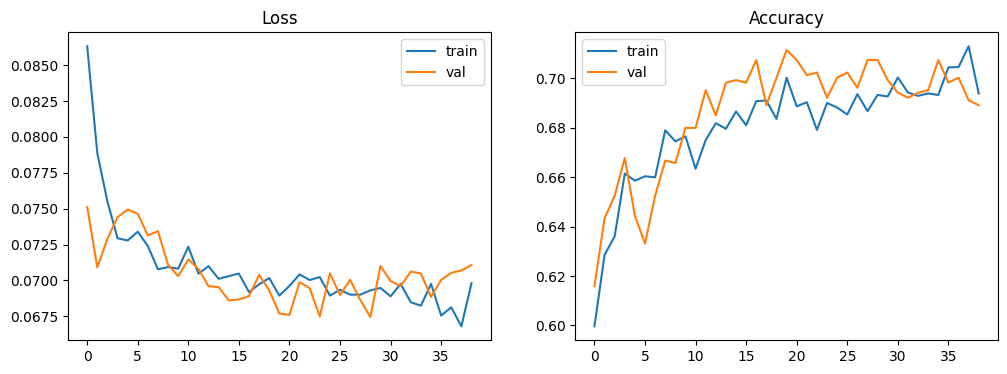

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.show()

              precision    recall  f1-score   support

    non_fire       0.64      0.68      0.66       411
        fire       0.76      0.73      0.74       573

    accuracy                           0.71       984
   macro avg       0.70      0.70      0.70       984
weighted avg       0.71      0.71      0.71       984



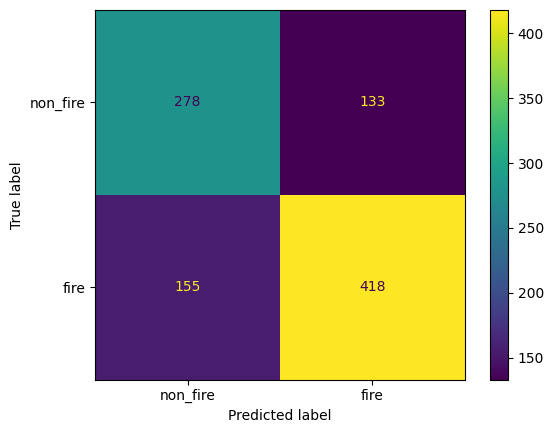

In [13]:
lstm_model.load_state_dict(torch.load(best_path, map_location=DEVICE))
lstm_model.eval()

all_probs = []
all_true = []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = lstm_model(xb.to(DEVICE))
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_true.extend(yb.numpy().tolist())

all_probs = np.asarray(all_probs)
all_true = np.asarray(all_true).astype(int)
all_pred = (all_probs >= 0.5).astype(int)

print(classification_report(all_true, all_pred, target_names=["non_fire", "fire"]))
cm = confusion_matrix(all_true, all_pred)
ConfusionMatrixDisplay(cm, display_labels=["non_fire", "fire"]).plot(values_format="d")
plt.show()

## 8. Сохранение артефактов

In [14]:
joblib.dump(scaler, CFG.artifacts_dir / "feature_scaler.joblib")

config_to_save = {
    "input_size": int(input_size),
    "hidden_size": CFG.hidden_size,
    "num_layers": CFG.num_layers,
    "dropout": CFG.dropout,
    "bidirectional": CFG.bidirectional,
    "seq_len": CFG.seq_len,
    "seq_stride": CFG.seq_stride,
    "frame_step": CFG.frame_step,
    "max_frames": CFG.max_frames,
    "img_size": CFG.img_size,
    "yolo_conf": CFG.yolo_conf,
    "use_yolo_trigger_crop": CFG.use_yolo_trigger_crop,
    "trigger_conf": CFG.trigger_conf,
    "trigger_consecutive_frames": CFG.trigger_consecutive_frames,
    "trigger_max_scan_frames": CFG.trigger_max_scan_frames,
    "yolo_weights": str(CFG.yolo_weights),
    "classes": {"0": "non_fire", "1": "fire"},
}
with open(CFG.artifacts_dir / "lstm_config.json", "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, ensure_ascii=False, indent=2)

print("Сохранено в", CFG.artifacts_dir.resolve())

Сохранено в C:\Users\2016n\OneDrive\Desktop\lstm\lstm_artifacts


## 9. Проверка на одном видео

Функция возвращает вероятность класса `fire`. Видео сначала обрезается по тому же YOLO-триггеру, затем итоговая вероятность считается как среднее по окнам LSTM.

In [24]:
def visualize_video_prediction(video_path: str, yolo_model, lstm_model, scaler, cfg: Config):
    """
    Открывает видео в новом окне, рисует боксы от YOLO и показывает 
    реалтайм вероятность пожара от LSTM, анализируя последние seq_len кадров.
    """
    import cv2
    import numpy as np
    import torch

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Ошибка: не могу открыть видео {video_path}")
        return

    features_buffer = []
    prev_gray = None
    frame_idx = 0
    current_prob = 0.0

    lstm_model.eval()

    print("Окно видео откроется через секунду. Для выхода нажмите 'q'.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]
        frame_area = h * w

        # Делаем предикт YOLO на кадре
        results_gen = yolo_model.predict(
            frame, imgsz=cfg.img_size, conf=cfg.yolo_conf, verbose=False, device=YOLO_DEVICE, stream=True
        )
        result = next(results_gen)
        
        # Получаем кадр с уже нарисованными боксами YOLO
        annotated_frame = result.plot()

        # Собираем фичи для LSTM с заданным шагом frame_step
        if frame_idx % cfg.frame_step == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray_small = cv2.resize(gray, (160, 90), interpolation=cv2.INTER_AREA)

            fire = class_stats(result.boxes, frame_area, cls_id=0)
            smoke = class_stats(result.boxes, frame_area, cls_id=1)
            motion = motion_features(prev_gray, gray_small)
            feature_vector = fire + smoke + motion

            features_buffer.append(feature_vector)
            
            # Поддерживаем размер окна ровно seq_len
            if len(features_buffer) > cfg.seq_len:
                features_buffer.pop(0)

            # Если накопили нужное количество кадров — делаем предсказание LSTM
            if len(features_buffer) == cfg.seq_len:
                feats_arr = np.array(features_buffer, dtype=np.float32)
                feats_scaled = scaler.transform(feats_arr)
                
                # Добавляем размерность батча: (1, seq_len, 12)
                xb = torch.tensor(feats_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                
                with torch.no_grad():
                    logits = lstm_model(xb)
                    prob = torch.sigmoid(logits).item()
                current_prob = prob

            prev_gray = gray_small

        frame_idx += 1

        # Отрисовка вероятности поверх кадра
        # Красный цвет, если уверенность > 50%, иначе зеленый
        color = (0, 0, 255) if current_prob > 0.5 else (0, 255, 0)
        
        # Создаем темную подложку под текст для читаемости
        cv2.rectangle(annotated_frame, (10, 10), (450, 80), (0, 0, 0), -1)
        text = f"LSTM Fire Prob: {current_prob * 100:.1f}%"
        cv2.putText(annotated_frame, text, (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 3)

        # Выводим кадр в окно
        cv2.imshow("Fire & Smoke Detection (YOLO + LSTM)", annotated_frame)
        
        # Выход по нажатию клавиши 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# ── Запуск примера ──
# Убедись, что путь к видео правильный!
video_path = "./The_Incredible_Power_of_a_Small_Battery_From_Spark_to_Disaster🔥.mp4"
visualize_video_prediction(video_path, model, lstm_model, scaler, CFG)

Окно видео откроется через секунду. Для выхода нажмите 'q'.
